# dive-bytecode-12 — bytecode-modality dive on the new diverse-synthetic dataset

**The hypothesis.** dive-11 measured the new diverse-synthetic on the **source** modality and
hit 0.7634 (vs old templated 0.747-ish on bytecode dive-5, scored on a different test). The
*original* synthetic-augmentation plan was bytecode-modality — source was the detour. This
notebook revives bytecode on the new diverse synthetic with a tighter preprocessing pipeline.

**Preprocessing (the new bit).** For each contract (real or synthetic):

1. Lookup hex bytecode (real → `Bytecode_filled.csv`, `buggy_*` → `final/Synthetic_Bytecode.csv`).
2. **Strip CBOR/SWARM metadata trailer** (Solc-embedded, non-executable; ~40% of contracts carry one).
3. **Hex → raw bytes**.
4. **Disassemble**: walk bytes, emit one opcode-mnemonic token per opcode.
5. **Strip PUSH operands**: for `PUSH1..PUSH32` (`0x60..0x7f`), advance past the 1–32 operand
   bytes but emit **only the opcode token** — no immediate value, no typed semantic token.
   Final vocab: `{PAD, CLS, SEP, UNK}` + 256 opcode slots = **260 tokens**.
6. **Deduplicate the TRAIN fold** by post-strip opcode-token sequence hash. Val/test are
   hash-pinned and untouched. Cross-fold duplicates reported as a leakage diagnostic.

**Arms** (set `AUG_SOURCE` in cell 2; run the notebook once per arm in the same session
so the per-arm `metrics_arm_*.json` accumulate and the final cell tabulates them):

| `AUG_SOURCE` | Train fold | Answers |
|---|---|---|
| `"none"` | real only | the control — does *any* synthetic help on bytecode? |
| `"buggy"` | real + new diverse synthetic | the test of the snippet diversification |

All arms share the **same val (2,233) and test (4,466) real folds**, the same model,
hparams, loss, calibration, thresholds, sampler, EMA, and seed.

**What stays identical to dive-5 / dive-11**
- Single-pass Transformer: `d_model=384`, 6 layers, 6 heads, `d_ff=1536`, RoPE, CNN stem
  (k=3 ∥ k=5), SDPA with memory-efficient backend, per-class MLP heads, aux BCE on BR+FR.
- `AsymmetricLossWeighted` (γ⁻=4, γ⁺=1, clip=0.05) + 0.3×BCE on (BR, FR).
- EMA decay 0.999, AdamW with selective weight decay, cosine warmup, grad clip 1.0.
- `WeightedRandomSampler` (sqrt-inv-freq, clipped `[1, 5]`).
- Isotonic per-class calibration → 41-pt threshold tune (min-precision 0.25 for support < 200).
- Span-mask augmentation + token-span CutMix collate.
- Atomic full-state checkpointing, tee logger, history.csv.

**Reading the result**
1. **Gates (cell 5):** leakage + identical-test must pass before training.
2. **`test_calibrated_tuned.f1_macro` per arm**, all on the 4,466 test — the headline.
3. **Per-class F1 on BR/FR/DoS** — the targeted rare classes.
4. **Per-class overfit gap** — should be smaller than templated synthetic if diversification helps.


## 1 — Environment

In [1]:
import os, re, gc, json, math, time, random, warnings, sys, traceback, hashlib
from pathlib import Path
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_gpus = torch.cuda.device_count()
print(f"Torch {torch.__version__} | CUDA {torch.cuda.is_available()} | GPUs {n_gpus}", flush=True)
for i in range(n_gpus):
    p = torch.cuda.get_device_properties(i)
    print(f"  GPU {i}: {p.name} | {p.total_memory/1e9:.1f} GB | sm_{p.major}{p.minor}", flush=True)


Torch 2.10.0+cu128 | CUDA True | GPUs 2
  GPU 0: Tesla T4 | 15.6 GB | sm_75
  GPU 1: Tesla T4 | 15.6 GB | sm_75


## 2 — Config

Edit **only** this cell to switch arms or to switch between fresh run and resume.

- `RESUME_FROM = None` → fresh training, fresh checkpoint at `last_state_<arm>.pt`.
- `RESUME_FROM = "/kaggle/working/last_state_<arm>.pt"` → continue from saved state.


In [2]:
# -- Paths --------------------------------------------------------------------
def _find_root(base):
    """Find dataset root: look for any directory named 'splits' or 'final' that
    contains at least one CSV — works regardless of exact file naming."""
    base = Path(base)
    if not base.exists():
        return None
    for d in sorted(base.rglob("*")):
        if d.is_dir() and d.name in ("splits", "final"):
            if any(d.glob("*.csv")):
                return d.parent
    return None

_DS_BASE = Path("/kaggle/input/datasets/henrychristian7555/dive-synthesized")
DATA_ROOT = _find_root(_DS_BASE) or _find_root(Path("/kaggle/input/dive-synthesized"))
if DATA_ROOT is None:
    if _DS_BASE.exists():
        print("Dataset base found. Contents:", flush=True)
        for _p in sorted(_DS_BASE.rglob("*")):
            if _p.is_dir() or _p.suffix == ".csv":
                print(f"  {_p.relative_to(_DS_BASE)}", flush=True)
    import kagglehub
    DATA_ROOT = _find_root(kagglehub.dataset_download("henrychristian7555/dive-synthesized"))
assert DATA_ROOT is not None, (
    f"dive-synthesized dataset not found — could not locate a 'splits/' or 'final/' "
    f"directory containing CSV files under {_DS_BASE}"
)

SPLIT_DIR  = DATA_ROOT / "splits"
_FINAL_DIR = DATA_ROOT / "final"

# Real bytecode (DIVE original) + synthetic bytecode (from the new diverse-injection campaign).
BYTECODE_CSV       = DATA_ROOT / "Bytecode_filled.csv"
SYNTH_BYTECODE_CSV = _FINAL_DIR / "Synthetic_Bytecode.csv"

def _fold_csv(name):
    cap = name.capitalize()
    candidates = (
        [_FINAL_DIR / f"{cap}_Labels.csv", SPLIT_DIR / f"{cap}_Labels.csv"]
        if name == "train"
        else [SPLIT_DIR / f"{cap}_Labels.csv", _FINAL_DIR / f"{cap}_Labels.csv"]
    )
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"No split CSV for fold '{name}' — tried: {candidates}")

def _is_synthetic(cid):
    try:
        return int(str(cid)) >= 1_000_000
    except (ValueError, TypeError):
        return True   # non-numeric IDs (e.g. buggy_1419_TOD) are synthetic

def _aug_kind(cid):
    """Classify a contractID for the augmentation ablation:
       'real'  — real Etherscan contract (numeric ID < 1,000,000),
       'llm'   — dive-9 LLM synthetic   (numeric ID >= 1,000,000) — not in this dataset,
       'buggy' — curated buggy_* / other non-numeric synthetic."""
    s = str(cid)
    if s.isdigit():
        return "llm" if int(s) >= 1_000_000 else "real"
    return "buggy"

# === ABLATION KNOB ===========================================================
# Which training-side augmentation to layer on top of the FIXED real train split.
# Run the notebook once per value in the same Kaggle session; per-arm metrics are
# written to metrics_arm_<AUG_SOURCE>.json and the final cell tabulates all arms.
#   "none"  -> real bytecode only (control)
#   "buggy" -> real + new diverse synthetic bytecode (the test of the diversification)
AUG_SOURCE = "buggy"
assert AUG_SOURCE in ("none", "buggy"), f"bad AUG_SOURCE {AUG_SOURCE!r}"

OUT_DIR     = Path("/kaggle/working");   OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR   = OUT_DIR / "cache";         CACHE_DIR.mkdir(parents=True, exist_ok=True)
_ARM        = AUG_SOURCE
LOG_PATH    = OUT_DIR / f"dive_bc12_{_ARM}_train.log"
HIST_CSV    = OUT_DIR / f"history_{_ARM}.csv"
HIST_JSON   = OUT_DIR / f"history_{_ARM}.json"
STATE_PATH  = OUT_DIR / f"last_state_{_ARM}.pt"
BEST_PATH   = OUT_DIR / f"best_model_{_ARM}.pt"
METRICS_ARM_JSON = OUT_DIR / f"metrics_arm_{_ARM}.json"

# -- Resume control -----------------------------------------------------------
RESUME_FROM = None    # set to str(STATE_PATH) to resume

# -- Labels -------------------------------------------------------------------
LABEL_COLS = ["Reentrancy", "Access Control", "Arithmetic", "Unchecked Return Values",
              "DoS", "Bad Randomness", "Front Running", "Time manipulation"]
N_LABELS = len(LABEL_COLS)
BR_IDX = LABEL_COLS.index("Bad Randomness")     # 5
FR_IDX = LABEL_COLS.index("Front Running")      # 6

# -- Opcode vocab (PUSH operands stripped: only opcode mnemonics + specials) --
PAD_ID, CLS_ID, SEP_ID, UNK_ID = 0, 1, 2, 3
OPCODE_OFFSET = 4                                # opcode b -> token (b + OPCODE_OFFSET)
VOCAB_SIZE    = OPCODE_OFFSET + 256              # 4 specials + 256 opcode slots = 260
SEQ_LEN       = 4096                             # single-pass context (dive-5)

# -- Model (dive-5 single-pass Transformer) -----------------------------------
D_MODEL   = 384
N_HEADS   = 6
N_LAYERS  = 6
D_FF      = 1536
DROPOUT   = 0.15
DROP_PATH = 0.10

# -- Training -----------------------------------------------------------------
BATCH_PER_GPU = 12                               # single forward / contract at L=SEQ_LEN
BATCH_SIZE    = BATCH_PER_GPU * max(1, n_gpus)
EPOCHS        = 25
LR            = 2e-4
WEIGHT_DECAY  = 0.05
GRAD_CLIP     = 1.0
WARMUP_RATIO  = 0.10
PATIENCE      = 8
NUM_WORKERS   = 2
PIN_MEMORY    = True

# -- Asymmetric Loss + aux BCE ------------------------------------------------
ASL_GAMMA_NEG = 4.0
ASL_GAMMA_POS = 1.0
ASL_CLIP      = 0.05
PER_CLASS_W_MIN = 1.0
PER_CLASS_W_MAX = 5.0
AUX_BCE_INDICES = [BR_IDX, FR_IDX]
AUX_BCE_WEIGHT  = 0.3

# -- EMA ----------------------------------------------------------------------
EMA_DECAY = 0.999

# -- Augmentation (token-level) -----------------------------------------------
AUG_SPAN_MASK_PROB = 0.08
AUG_SPAN_MAX_LEN   = 3
AUG_CUTMIX_PROB    = 0.30
AUG_CUTMIX_BETA    = 0.5

# -- Sampler ------------------------------------------------------------------
SAMPLER_W_MIN = 1.0
SAMPLER_W_MAX = 5.0

# -- Checkpointing ------------------------------------------------------------
CKPT_WALLCLOCK_SECS = 30 * 60

# -- Verification gates -------------------------------------------------------
MIN_BYTECODE_COVERAGE  = 0.99    # >=99% of label rows must have a bytecode entry
MIN_COVERAGE_AT_SEQ_LEN = 0.85    # >=85% of contracts must fit in SEQ_LEN tokens

# -- Sanity check on data files -----------------------------------------------
assert SPLIT_DIR.exists() or _FINAL_DIR.exists(), f"Missing splits dir {SPLIT_DIR}"
assert BYTECODE_CSV.exists(), f"Missing real bytecode CSV {BYTECODE_CSV}"
if AUG_SOURCE == "buggy":
    assert SYNTH_BYTECODE_CSV.exists(), (
        f"AUG_SOURCE='buggy' but synthetic bytecode CSV is missing: {SYNTH_BYTECODE_CSV}. "
        f"Either re-upload Dataset/final/Synthetic_Bytecode.csv, or set AUG_SOURCE='none'.")
print("Inputs OK:", DATA_ROOT, flush=True)
print("RESUME_FROM:", RESUME_FROM, flush=True)
print(f"Vocab: {VOCAB_SIZE} tokens (PUSH operands stripped) | SEQ_LEN={SEQ_LEN}", flush=True)
print(f"Model: d_model={D_MODEL} n_heads={N_HEADS} n_layers={N_LAYERS} d_ff={D_FF}", flush=True)


Inputs OK: /kaggle/input/datasets/henrychristian7555/dive-synthesized/Dataset
RESUME_FROM: None
Vocab: 260 tokens (PUSH operands stripped) | SEQ_LEN=4096
Model: d_model=384 n_heads=6 n_layers=6 d_ff=1536


## 3 — `tee` logger

Mirrors stdout to `dive_bc12_<arm>_train.log`. Reopened in append mode so it survives
Kaggle "Save Version" and resumes.


In [3]:
class TeeLogger:
    def __init__(self, path: Path):
        self.path = path
        self.fh = open(path, "a", buffering=1, encoding="utf-8")
        self.fh.write(f"\n===== run started {datetime.utcnow().isoformat()}Z =====\n")
        self.fh.flush()

    def __call__(self, msg: str = ""):
        ts = datetime.utcnow().strftime("%H:%M:%S")
        line = f"[{ts}] {msg}"
        print(line, flush=True)
        self.fh.write(line + "\n"); self.fh.flush()

    def close(self):
        try: self.fh.close()
        except Exception: pass

log = TeeLogger(LOG_PATH)
log(f"Logger writing to {LOG_PATH}")
log(f"GPUs available: {n_gpus}")
log(f"AUG_SOURCE = {AUG_SOURCE!r}")


[14:48:12] Logger writing to /kaggle/working/dive_bc12_buggy_train.log
[14:48:12] GPUs available: 2
[14:48:12] AUG_SOURCE = 'buggy'


## 4 — Load bytecode (real + synthetic) into one in-memory map

Streams `Bytecode_filled.csv` (real contracts, ~330 MB) and (if the buggy arm) the synthetic
`Dataset/final/Synthetic_Bytecode.csv` into a single `contractID -> hex` dict. Real IDs are
numeric strings (`'1'`, `'2'`, ...); synthetic IDs are `buggy_<id>_<type>`. The keys here drive
the fold-level "bytecode coverage" gate in cell 5.


In [4]:
def _load_bc_csv(path, label):
    d = pd.read_csv(path, usecols=["contractID", "bytecode"],
                    dtype={"contractID": str})
    n0 = len(d)
    d = d.dropna(subset=["bytecode"])
    d = d[d["bytecode"].astype(str).str.len() > 4]
    log(f"  {label:>10s}: {len(d):6d} / {n0:6d} rows with bytecode  ({path.name})")
    return dict(zip(d["contractID"].astype(str), d["bytecode"].astype(str)))


log("Loading bytecode CSVs...")
bytecode_map = _load_bc_csv(BYTECODE_CSV, "real")

if AUG_SOURCE == "buggy" and SYNTH_BYTECODE_CSV.exists():
    syn_map = _load_bc_csv(SYNTH_BYTECODE_CSV, "synthetic")
    # Synthetic IDs are 'buggy_*' strings → no collision with real numeric IDs.
    overlap = set(bytecode_map) & set(syn_map)
    if overlap:
        log(f"  WARNING: {len(overlap)} ID collision(s) between real and synthetic — synthetic wins.")
    bytecode_map.update(syn_map)

log(f"Combined bytecode map: {len(bytecode_map):,} unique IDs")


[14:48:12] Loading bytecode CSVs...
[14:48:18]         real:  22330 /  22330 rows with bytecode  (Bytecode_filled.csv)
[14:48:21]    synthetic:   5400 /   5400 rows with bytecode  (Synthetic_Bytecode.csv)
[14:48:21] Combined bytecode map: 27,730 unique IDs


## 5 — Load folds, apply `AUG_SOURCE`, run the verification gates

`val`/`test` are loaded once and are **fixed across all arms** (the real-only benchmark).
The `train` fold is loaded in full (real + curated buggy_*) and then **filtered by `AUG_SOURCE`**.

Two gate blocks run **before** any preprocessing:
1. **Leakage** — train∩test = train∩val = val∩test = 0, and val/test carry no synthetic IDs.
2. **Identical-test** — the test fold equals the recorded dataset-generation 4,466-row
   benchmark (row count + per-class support).


In [5]:
def _load_fold_raw(name):
    d = pd.read_csv(_fold_csv(name))
    d["contractID"] = d["contractID"].astype(str)
    have = d["contractID"].apply(lambda c: c in bytecode_map)
    cov = have.mean()
    log(f"  {name:>5s} (raw): {len(d):6d} rows | bytecode coverage {cov:.2%}")
    if cov < 1.0:
        log(f"    dropping {int((~have).sum())} rows with no bytecode")
    return d[have].reset_index(drop=True)


# --- val / test: FIXED across every arm (the real-only benchmark) ------------
val_df  = _load_fold_raw("val")
test_df = _load_fold_raw("test")

# --- train fold: load full (real + buggy), then filter by AUG_SOURCE ---------
train_full = _load_fold_raw("train")
train_full["_kind"] = train_full["contractID"].apply(_aug_kind)
_kc = train_full["_kind"].value_counts().to_dict()
log(f"Train fold raw composition: real={_kc.get('real',0)} "
    f"buggy={_kc.get('buggy',0)} llm={_kc.get('llm',0)}")

real_df = train_full[train_full["_kind"] == "real"].copy()

if AUG_SOURCE == "none":
    train_df = real_df
else:  # "buggy"
    train_df = train_full[train_full["_kind"].isin(["real", "buggy"])].copy()

train_df = train_df.drop(columns=["_kind"], errors="ignore").reset_index(drop=True)

# ===== VERIFICATION GATES (must pass before any preprocessing/training) ======
def _ids(d):
    return set(d["contractID"].astype(str))

tr_ids, v_ids, te_ids = _ids(train_df), _ids(val_df), _ids(test_df)
tr_real = {c for c in tr_ids if _aug_kind(c) == "real"}

g_tr_te, g_tr_v, g_v_te = tr_ids & te_ids, tr_ids & v_ids, v_ids & te_ids
log(f"[gate] leakage  train∩test={len(g_tr_te)}  train∩val={len(g_tr_v)}  val∩test={len(g_v_te)}")
assert not g_tr_te, f"LEAKAGE: {len(g_tr_te)} train IDs in test (e.g. {list(g_tr_te)[:5]})"
assert not g_tr_v,  f"LEAKAGE: {len(g_tr_v)} train IDs in val"
assert not g_v_te,  f"LEAKAGE: {len(g_v_te)} val IDs in test"
n_syn_eval = int(pd.concat([val_df, test_df])["contractID"].apply(_is_synthetic).sum())
assert n_syn_eval == 0, f"LEAKAGE: {n_syn_eval} synthetic rows in val/test"

EXPECTED_TEST_ROWS = 4466
EXPECTED_TEST_SUPPORT = {
    "Reentrancy": 2280, "Access Control": 3345, "Arithmetic": 1909,
    "Unchecked Return Values": 1182, "DoS": 756, "Bad Randomness": 127,
    "Front Running": 121, "Time manipulation": 1265}
_sup = {c: int(test_df[c].sum()) for c in LABEL_COLS}
log(f"[gate] test rows={len(test_df)} (expect {EXPECTED_TEST_ROWS})")
log(f"[gate] test support={_sup}")
if len(test_df) != EXPECTED_TEST_ROWS or _sup != EXPECTED_TEST_SUPPORT:
    log("[gate] WARNING: this test set does NOT match the recorded 4,466-row benchmark. "
        "Arms remain comparable to EACH OTHER (same test this session) but NOT to dive-11.")
else:
    log("[gate] OK: test set == recorded 4,466-row real benchmark.")

# ----------------------------------------------------------------------------
df = pd.concat([train_df, val_df, test_df], ignore_index=True)
log(f"ARM={AUG_SOURCE} | working set {df.shape} | "
    f"train={len(train_df)} (real={len(tr_real)}, aug={len(train_df)-len(tr_real)}) "
    f"val={len(val_df)} test={len(test_df)}")
log("Positives per class (train fold):")
for c in LABEL_COLS:
    log(f"  {c:>26s}  {int(train_df[c].sum()):>5d}")


[14:48:21]     val (raw):   2233 rows | bytecode coverage 100.00%
[14:48:21]    test (raw):   4466 rows | bytecode coverage 100.00%
[14:48:21]   train (raw):  21031 rows | bytecode coverage 100.00%
[14:48:21] Train fold raw composition: real=15631 buggy=5400 llm=0
[14:48:21] [gate] leakage  train∩test=0  train∩val=0  val∩test=0
[14:48:21] [gate] test rows=4466 (expect 4466)
[14:48:21] [gate] test support={'Reentrancy': 2280, 'Access Control': 3345, 'Arithmetic': 1909, 'Unchecked Return Values': 1182, 'DoS': 756, 'Bad Randomness': 127, 'Front Running': 121, 'Time manipulation': 1265}
[14:48:21] [gate] OK: test set == recorded 4,466-row real benchmark.
[14:48:21] ARM=buggy | working set (27730, 9) | train=21031 (real=15631, aug=5400) val=2233 test=4466
[14:48:21] Positives per class (train fold):
[14:48:21]                   Reentrancy  10704
[14:48:21]               Access Control  16161
[14:48:21]                   Arithmetic   8560
[14:48:21]      Unchecked Return Values   5423
[14:48

## 6 — Fold indices ( pre-split, no re-splitting )

In [6]:
Y = df[LABEL_COLS].values.astype(np.float32)

n_tr, n_v, n_te = len(train_df), len(val_df), len(test_df)
idx_tr = np.arange(0, n_tr)
idx_v  = np.arange(n_tr, n_tr + n_v)
idx_te = np.arange(n_tr + n_v, n_tr + n_v + n_te)

log(f"Train {len(idx_tr)} | Val {len(idx_v)} | Test {len(idx_te)}")
for i, lab in enumerate(LABEL_COLS):
    log(f"  {lab:>26s}  tr={int(Y[idx_tr,i].sum()):>5d}  "
        f"v={int(Y[idx_v,i].sum()):>4d}  te={int(Y[idx_te,i].sum()):>4d}")


[14:48:21] Train 21031 | Val 2233 | Test 4466
[14:48:21]                   Reentrancy  tr=10704  v=1140  te=2280
[14:48:21]               Access Control  tr=16161  v=1672  te=3345
[14:48:21]                   Arithmetic  tr= 8560  v= 954  te=1909
[14:48:21]      Unchecked Return Values  tr= 5423  v= 591  te=1182
[14:48:21]                          DoS  tr= 5117  v= 378  te= 756
[14:48:21]               Bad Randomness  tr= 1933  v=  63  te= 127
[14:48:21]                Front Running  tr= 2024  v=  61  te= 121
[14:48:21]            Time manipulation  tr= 5957  v= 632  te=1265


## 7 — Bytecode preprocessing: strip metadata → disassemble → strip PUSH operands → dedup

The five preprocessing items the user listed, plus train-fold deduplication.

**`strip_metadata`** (verbatim from dive-5). Solc embeds a CBOR-encoded trailer at the
end of deployed bytecode containing the compiler version + IPFS/Swarm hash. The last 2
bytes are the trailer length L (big-endian); if `b[-(L+2)]` is a CBOR map marker
(`0xa1` or `0xa2`), strip `L+2` bytes — pure noise, ~40% of contracts carry one.

**`disassemble_strip_push`**. Walk bytes; emit one opcode-mnemonic token per opcode
(`op + OPCODE_OFFSET`). For `PUSH1..PUSH32` (`0x60..0x7f`), advance past the 1..32 operand
bytes but **do not emit any immediate token** — selectors, addresses, constants are all
dropped. Final vocab = `{PAD, CLS, SEP, UNK}` + 256 opcode slots = 260 tokens.

**Train-fold dedup** (leakage-safe). Hash each train contract's post-strip opcode-token
sequence (MD5 of the int32 array). Group by hash; keep one contract per group (lowest IDs
first; `buggy_*` always kept since each is structurally unique by construction). Val/test
are hash-pinned by the dataset and not touched. Cross-fold opcode-sequence duplicates are
reported but NOT removed — they flag modality-level leakage that contractID-level gates miss.


In [7]:
def strip_metadata(bc_hex: str):
    """Strip CBOR metadata trailer if present. Returns (hex_str, was_stripped). (dive-5)"""
    s = bc_hex.strip().lower()
    if s.startswith("0x"):
        s = s[2:]
    if len(s) < 6 or (len(s) & 1):
        return s, False
    try:
        b = bytes.fromhex(s)
    except ValueError:
        return s, False
    n = len(b)
    if n < 4:
        return s, False
    L = int.from_bytes(b[-2:], "big")
    if L < 2 or L + 2 > n:
        return s, False
    head_byte = b[-(L + 2)]
    if head_byte not in (0xa1, 0xa2):
        return s, False
    return b[:-(L + 2)].hex(), True


def disassemble_strip_push(bc_hex: str, max_len: int = SEQ_LEN):
    """Disassemble hex bytecode -> opcode-token list with PUSH operands stripped.

    For each byte b:
      - emit (b + OPCODE_OFFSET) as the opcode token,
      - if 0x60 <= b <= 0x7f (PUSH1..PUSH32), skip the next (b - 0x5f) operand bytes
        without emitting any immediate token.
    Output starts with [CLS_ID] and is truncated at max_len.
    """
    s, _ = strip_metadata(bc_hex)
    if len(s) < 2 or (len(s) & 1):
        return [CLS_ID]
    try:
        b = bytes.fromhex(s)
    except ValueError:
        return [CLS_ID]
    toks = [CLS_ID]
    i, n = 0, len(b)
    while i < n and len(toks) < max_len:
        op = b[i]
        toks.append(op + OPCODE_OFFSET)
        if 0x60 <= op <= 0x7f:
            imm_len = op - 0x5f  # 1..32
            i += 1 + imm_len
        else:
            i += 1
    return toks


t0 = time.time()
n_meta_stripped = 0
token_lists = []
for cid in df["contractID"].astype(str).values:
    hex_str = bytecode_map[cid]
    s, stripped = strip_metadata(hex_str)
    n_meta_stripped += int(stripped)
    token_lists.append(disassemble_strip_push(hex_str, SEQ_LEN))
log(f"Disassembled {len(token_lists)} contracts in {time.time()-t0:.1f}s | "
    f"CBOR metadata stripped: {n_meta_stripped} ({n_meta_stripped/max(1,len(token_lists)):.2%})")

lens = np.array([len(t) for t in token_lists])
coverage_at_seq = (lens <= SEQ_LEN).mean()
log(f"Opcode-token length: median={int(np.median(lens))}, "
    f"p75={int(np.percentile(lens,75))}, p90={int(np.percentile(lens,90))}, "
    f"p99={int(np.percentile(lens,99))}, max={int(lens.max())}")
log(f"Truncated at SEQ_LEN={SEQ_LEN}: {(lens>=SEQ_LEN).mean():.2%}")
log(f"Coverage @ SEQ_LEN: {coverage_at_seq:.2%}  (required >= {MIN_COVERAGE_AT_SEQ_LEN:.0%})")
assert coverage_at_seq >= MIN_COVERAGE_AT_SEQ_LEN, (
    f"Only {coverage_at_seq:.2%} of contracts fit in SEQ_LEN={SEQ_LEN}. "
    f"Raise SEQ_LEN or accept higher truncation.")

# ── dedup train fold by post-strip opcode-token sequence hash ────────────────
def _seq_hash(toks):
    return hashlib.md5(np.asarray(toks, dtype=np.int32).tobytes()).hexdigest()

hashes = [_seq_hash(t) for t in token_lists]

cids_all = df["contractID"].astype(str).values
train_seen = {}      # hash -> kept row index
kept_train_rows = []
duplicates_within_train = 0
# Prefer to keep `buggy_*` synthetic rows over real rows when a hash collides — each
# synthetic is structurally unique by construction; collisions are usually real twins.
def _dedup_priority(row):
    return 0 if _aug_kind(cids_all[row]) == "buggy" else 1

for row in sorted(idx_tr, key=_dedup_priority):
    h = hashes[row]
    if h not in train_seen:
        train_seen[h] = row
        kept_train_rows.append(row)
    else:
        duplicates_within_train += 1

# Cross-fold duplicate diagnostic (NOT removed)
val_hashes  = {hashes[r]: r for r in idx_v}
test_hashes = {hashes[r]: r for r in idx_te}
train_kept_h = {hashes[r] for r in kept_train_rows}
n_train_in_val  = sum(1 for h in train_kept_h if h in val_hashes)
n_train_in_test = sum(1 for h in train_kept_h if h in test_hashes)
n_val_in_test   = sum(1 for h in val_hashes if h in test_hashes)

log(f"[dedup] train duplicates removed: {duplicates_within_train}/{len(idx_tr)} "
    f"({duplicates_within_train/max(1,len(idx_tr)):.2%}) -> {len(kept_train_rows)} unique")
log(f"[dedup-diagnostic] cross-fold opcode-sequence duplicates (NOT removed — flagged):")
log(f"   train opcode-seq IN val:  {n_train_in_val}")
log(f"   train opcode-seq IN test: {n_train_in_test}")
log(f"   val   opcode-seq IN test: {n_val_in_test}")

idx_tr = np.array(sorted(kept_train_rows), dtype=np.int64)
log(f"Final train fold: {len(idx_tr)} contracts after dedup "
    f"({len(idx_tr)/max(1,n_tr):.1%} of pre-dedup train)")

# ── pad/truncate to (N, SEQ_LEN) flat tensors ────────────────────────────────
def _to_padded_flat(tok_subset, max_len=SEQ_LEN):
    n = len(tok_subset)
    X  = np.zeros((n, max_len), dtype=np.int32)
    TM = np.zeros((n, max_len), dtype=np.bool_)
    for i, t in enumerate(tok_subset):
        L = min(len(t), max_len)
        X[i, :L]  = t[:L]
        TM[i, :L] = True
    return X, TM


t0 = time.time()
X_tr, TM_tr = _to_padded_flat([token_lists[i] for i in idx_tr])
X_v,  TM_v  = _to_padded_flat([token_lists[i] for i in idx_v])
X_te, TM_te = _to_padded_flat([token_lists[i] for i in idx_te])
Y_tr, Y_v, Y_te = Y[idx_tr], Y[idx_v], Y[idx_te]
log(f"Padded in {time.time()-t0:.1f}s | X_tr {X_tr.shape} | "
    f"mean real-token frac (train) = {TM_tr.mean():.3f}")

# Free the raw token lists — we have the dense tensors now.
del token_lists, hashes
gc.collect()


[14:48:38] Disassembled 27730 contracts in 16.6s | CBOR metadata stripped: 27626 (99.62%)
[14:48:38] Opcode-token length: median=4096, p75=4096, p90=4096, p99=4096, max=4096
[14:48:38] Truncated at SEQ_LEN=4096: 55.33%
[14:48:38] Coverage @ SEQ_LEN: 100.00%  (required >= 85%)
[14:48:42] [dedup] train duplicates removed: 5745/21031 (27.32%) -> 15286 unique
[14:48:42] [dedup-diagnostic] cross-fold opcode-sequence duplicates (NOT removed — flagged):
[14:48:42]    train opcode-seq IN val:  583
[14:48:42]    train opcode-seq IN test: 900
[14:48:42]    val   opcode-seq IN test: 331
[14:48:42] Final train fold: 15286 contracts after dedup (72.7% of pre-dedup train)
[14:48:45] Padded in 2.8s | X_tr (15286, 4096) | mean real-token frac (train) = 0.823


0

## 8 — Dataset + span-mask augmentation (verbatim from dive-5)

Per-position span masking: with `AUG_SPAN_MASK_PROB`, replace a 1..`AUG_SPAN_MAX_LEN`-token
span with `PAD_ID`. CLS at position 0 is protected.


In [8]:
def span_mask_flat(x: np.ndarray, tm: np.ndarray):
    """In-place-style span masking on (SEQ_LEN,) arrays. Position 0 (CLS) protected."""
    x  = x.copy()
    tm = tm.copy()
    L = x.shape[0]
    j = 1
    while j < L:
        if not tm[j]:
            break
        if np.random.rand() < AUG_SPAN_MASK_PROB:
            span = np.random.randint(1, AUG_SPAN_MAX_LEN + 1)
            end = min(j + span, L)
            x[j:end]  = PAD_ID
            tm[j:end] = False
            j = end
        else:
            j += 1
    return x, tm


class OpcodeDS(Dataset):
    def __init__(self, X, TM, Y, augment: bool = False):
        self.X, self.TM, self.Y = X, TM, Y
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        x, tm = self.X[i], self.TM[i]
        if self.augment:
            x, tm = span_mask_flat(x, tm)
        return (torch.from_numpy(x).long(),
                torch.from_numpy(tm),
                torch.from_numpy(self.Y[i]))


ds_tr = OpcodeDS(X_tr, TM_tr, Y_tr, augment=True)
ds_v  = OpcodeDS(X_v,  TM_v,  Y_v,  augment=False)
ds_te = OpcodeDS(X_te, TM_te, Y_te, augment=False)
log(f"Datasets ready: train={len(ds_tr)} val={len(ds_v)} test={len(ds_te)}")
log(f"  aug: span_mask_prob={AUG_SPAN_MASK_PROB} (max_len={AUG_SPAN_MAX_LEN}), "
    f"cutmix={AUG_CUTMIX_PROB} (beta={AUG_CUTMIX_BETA})")


[14:48:45] Datasets ready: train=15286 val=2233 test=4466
[14:48:45]   aug: span_mask_prob=0.08 (max_len=3), cutmix=0.3 (beta=0.5)


## 9 — Class-balanced sampler + token-span CutMix collate (verbatim from dive-5)

Sampler: per-sample weight = `max over positive labels of sqrt(N / class_count)`, clipped
`[1, 5]`. CutMix: with probability `AUG_CUTMIX_PROB`, swap a `lam ~ Beta(.5,.5)`-sized
contiguous token span between batch and its random permutation. CLS at position 0 protected.


In [9]:
def build_sampler_weights(Y_train: np.ndarray):
    counts = Y_train.sum(0).clip(min=1)
    inv = np.sqrt(Y_train.shape[0] / counts).astype(np.float32)
    has_pos = Y_train.sum(1) > 0
    w = np.where(has_pos, (Y_train * inv[None, :]).max(1), 1.0).astype(np.float32)
    w = np.clip(w, SAMPLER_W_MIN, SAMPLER_W_MAX)
    return w, inv, counts


sampler_w, inv_freq, class_counts = build_sampler_weights(Y_tr)
log("Per-class train counts and sqrt-inverse-freq weights:")
for i, lab in enumerate(LABEL_COLS):
    log(f"  {lab:>26s}  n={int(class_counts[i]):>5d}  inv_w={inv_freq[i]:.2f}")
log(f"Sampler weights: min={sampler_w.min():.2f}, median={np.median(sampler_w):.2f}, max={sampler_w.max():.2f}")

train_sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sampler_w).double(),
    num_samples=len(sampler_w),
    replacement=True,
)


def cutmix_collate_flat(batch):
    X  = torch.stack([b[0] for b in batch], dim=0)   # (B, L)
    TM = torch.stack([b[1] for b in batch], dim=0)
    Y  = torch.stack([b[2] for b in batch], dim=0)

    if AUG_CUTMIX_PROB <= 0 or np.random.rand() >= AUG_CUTMIX_PROB:
        return X, TM, Y

    B, L = X.shape
    perm = torch.randperm(B)
    lam = float(np.random.beta(AUG_CUTMIX_BETA, AUG_CUTMIX_BETA))
    span = int(np.ceil(lam * L)); span = max(1, min(L - 1, span))
    start = int(np.random.randint(1, max(2, L - span + 1)))   # CLS at 0 protected
    end = start + span

    X_mix  = X.clone()
    TM_mix = TM.clone()
    X_mix[:, start:end]  = X[perm][:, start:end]
    TM_mix[:, start:end] = TM[perm][:, start:end]

    real_i = TM[:, :start].float().sum(1) + TM[:, end:].float().sum(1)
    real_j = TM[perm][:, start:end].float().sum(1)
    total  = (real_i + real_j).clamp(min=1.0)
    lam_eff = (real_i / total).unsqueeze(1)
    Y_mix = lam_eff * Y + (1.0 - lam_eff) * Y[perm]
    return X_mix, TM_mix, Y_mix


[14:48:45] Per-class train counts and sqrt-inverse-freq weights:
[14:48:45]                   Reentrancy  n= 7684  inv_w=1.41
[14:48:45]               Access Control  n=11915  inv_w=1.13
[14:48:45]                   Arithmetic  n= 6364  inv_w=1.55
[14:48:45]      Unchecked Return Values  n= 3868  inv_w=1.99
[14:48:45]                          DoS  n= 4085  inv_w=1.93
[14:48:45]               Bad Randomness  n= 1575  inv_w=3.12
[14:48:45]                Front Running  n= 1645  inv_w=3.05
[14:48:45]            Time manipulation  n= 4852  inv_w=1.77
[14:48:45] Sampler weights: min=1.00, median=1.93, max=3.12


## 10 — Model: SDPA Transformer with RoPE, per-class MLP heads, aux BCE (verbatim from dive-5)

Token embedding → CNN stem (`Conv1d(k=3)` ∥ `Conv1d(k=5)`) → 6× pre-norm Transformer block
(`F.scaled_dot_product_attention` with RoPE applied to Q/K and a `(B,1,1,L)` boolean padding
mask) → mean ⊕ attn pool over real tokens → shared trunk → 8 parallel 2-layer MLP heads +
`Linear(2d → 2)` aux head for (BR, FR).


In [10]:
class DropPath(nn.Module):
    def __init__(self, p: float):
        super().__init__()
        self.p = p

    def forward(self, x):
        if not self.training or self.p == 0.0:
            return x
        keep = 1.0 - self.p
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        mask = x.new_empty(shape).bernoulli_(keep)
        return x * mask / keep


def _rotate_half(x):
    x1 = x[..., : x.shape[-1] // 2]
    x2 = x[..., x.shape[-1] // 2:]
    return torch.cat([-x2, x1], dim=-1)


def _apply_rope(q, k, cos, sin):
    cos_full = torch.cat([cos, cos], dim=-1).unsqueeze(0).unsqueeze(0)
    sin_full = torch.cat([sin, sin], dim=-1).unsqueeze(0).unsqueeze(0)
    q_rot = q * cos_full + _rotate_half(q) * sin_full
    k_rot = k * cos_full + _rotate_half(k) * sin_full
    return q_rot, k_rot


class MHAWithRoPE(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        assert d_model % n_heads == 0
        self.h = n_heads
        self.d = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model, bias=True)
        self.out = nn.Linear(d_model, d_model, bias=True)
        self.dropout = dropout

    def forward(self, x, attn_mask, cos, sin):
        B, L, D = x.shape
        qkv = self.qkv(x).reshape(B, L, 3, self.h, self.d).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        cos_d = cos.to(dtype=q.dtype, device=q.device)
        sin_d = sin.to(dtype=q.dtype, device=q.device)
        q, k = _apply_rope(q, k, cos_d, sin_d)
        out = F.scaled_dot_product_attention(
            q, k, v, attn_mask=attn_mask,
            dropout_p=self.dropout if self.training else 0.0,
            is_causal=False)
        out = out.transpose(1, 2).contiguous().reshape(B, L, D)
        return self.out(out)


class PreNormTxBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout, drop_path):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.mha = MHAWithRoPE(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model))
        self.drop1 = nn.Dropout(dropout)
        self.drop2 = nn.Dropout(dropout)
        self.dp1 = DropPath(drop_path)
        self.dp2 = DropPath(drop_path)

    def forward(self, x, attn_mask, cos, sin):
        h = self.ln1(x)
        a = self.mha(h, attn_mask, cos, sin)
        x = x + self.dp1(self.drop1(a))
        h = self.ln2(x)
        x = x + self.dp2(self.drop2(self.ff(h)))
        return x


class BytecodeTxModel(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, num_classes=N_LABELS,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 d_ff=D_FF, max_len=SEQ_LEN, dropout=DROPOUT, drop_path=DROP_PATH,
                 aux_dim=2):
        super().__init__()
        self.n_heads = n_heads
        self.max_len = max_len
        head_dim = d_model // n_heads
        assert head_dim % 2 == 0, f"head_dim={head_dim} must be even for RoPE"

        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.emb_norm  = nn.LayerNorm(d_model)
        self.emb_drop  = nn.Dropout(dropout)

        self.conv3 = nn.Conv1d(d_model, d_model // 2, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(d_model, d_model // 2, kernel_size=5, padding=2)
        self.conv_norm = nn.LayerNorm(d_model)

        dp_rates = [drop_path * i / max(1, n_layers - 1) for i in range(n_layers)]
        self.layers = nn.ModuleList([
            PreNormTxBlock(d_model, n_heads, d_ff, dropout, dp_rates[i])
            for i in range(n_layers)])
        self.final_norm = nn.LayerNorm(d_model)

        self.attn_score = nn.Linear(d_model, 1)

        inv_freq = 1.0 / (10000.0 ** (torch.arange(0, head_dim, 2).float() / head_dim))
        t = torch.arange(max_len).float()
        freqs = torch.outer(t, inv_freq)
        self.register_buffer("rope_cos", torch.cos(freqs), persistent=False)
        self.register_buffer("rope_sin", torch.sin(freqs), persistent=False)

        pool_dim = 2 * d_model
        self.head_shared = nn.Sequential(
            nn.LayerNorm(pool_dim), nn.Linear(pool_dim, d_model), nn.GELU(), nn.Dropout(dropout))
        self.class_heads = nn.ModuleList([
            nn.Sequential(nn.Linear(d_model, d_model // 2), nn.GELU(), nn.Linear(d_model // 2, 1))
            for _ in range(num_classes)])
        self.aux_head = nn.Linear(pool_dim, aux_dim)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.trunc_normal_(m.weight, std=0.02)
                with torch.no_grad():
                    m.weight[PAD_ID].zero_()

    def forward(self, input_ids, tok_mask):
        B, L = input_ids.shape
        x = self.token_emb(input_ids)
        x = self.emb_drop(self.emb_norm(x))

        c = x.transpose(1, 2)
        c = torch.cat([F.gelu(self.conv3(c)), F.gelu(self.conv5(c))], dim=1)
        x = self.conv_norm(x + c.transpose(1, 2))

        attn_mask = tok_mask.view(B, 1, 1, L)
        cos = self.rope_cos[:L]
        sin = self.rope_sin[:L]
        for layer in self.layers:
            x = layer(x, attn_mask, cos, sin)
        x = self.final_norm(x)

        mf = tok_mask.float().unsqueeze(-1)
        denom = mf.sum(1).clamp(min=1.0)
        mean_pool = (x * mf).sum(1) / denom

        s = self.attn_score(x).squeeze(-1).masked_fill(~tok_mask, -1e4)
        w = F.softmax(s, dim=-1).unsqueeze(-1)
        attn_pool = (x * w).sum(1)

        pooled = torch.cat([mean_pool, attn_pool], dim=-1)
        shared = self.head_shared(pooled)
        main_logits = torch.cat([h(shared) for h in self.class_heads], dim=-1)
        aux_logits  = self.aux_head(pooled)
        return main_logits, aux_logits


_m = BytecodeTxModel()
n_params = sum(p.numel() for p in _m.parameters())
log(f"Model parameters: {n_params/1e6:.2f} M  ({n_params:,})")
del _m; gc.collect()


[14:48:45] Model parameters: 12.23 M  (12,230,795)


0

## 11 — Loss: AsymmetricLoss (per-class weighted) + aux BCE on BR, FR (verbatim from dive-5/11)

In [11]:
class AsymmetricLossWeighted(nn.Module):
    def __init__(self, class_weights: np.ndarray,
                 gamma_neg=ASL_GAMMA_NEG, gamma_pos=ASL_GAMMA_POS, clip=ASL_CLIP, eps=1e-8):
        super().__init__()
        self.register_buffer("class_weights", torch.from_numpy(class_weights.astype(np.float32)))
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.eps = eps

    def forward(self, logits, targets):
        logits = logits.float()
        x_sig = torch.sigmoid(logits)
        xs_pos = x_sig
        xs_neg = 1.0 - x_sig
        if self.clip is not None and self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1.0)
        los_pos = targets * torch.log(xs_pos.clamp(min=self.eps))
        los_neg = (1.0 - targets) * torch.log(xs_neg.clamp(min=self.eps))
        loss = los_pos + los_neg
        if self.gamma_neg > 0 or self.gamma_pos > 0:
            pt0 = xs_pos * targets
            pt1 = xs_neg * (1.0 - targets)
            pt = pt0 + pt1
            one_sided_gamma = self.gamma_pos * targets + self.gamma_neg * (1.0 - targets)
            one_sided_w = torch.pow(1.0 - pt, one_sided_gamma)
            loss = loss * one_sided_w
        cw = self.class_weights.to(loss.device)
        loss = loss * cw.unsqueeze(0)
        return -loss.mean()


class ASLPlusAuxBCE(nn.Module):
    def __init__(self, asl: AsymmetricLossWeighted, aux_indices, aux_weight=AUX_BCE_WEIGHT):
        super().__init__()
        self.asl = asl
        self.register_buffer("aux_idx", torch.tensor(aux_indices, dtype=torch.long))
        self.aux_weight = float(aux_weight)
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, main_logits, aux_logits, targets):
        main_loss = self.asl(main_logits, targets)
        aux_targets = targets.index_select(1, self.aux_idx.to(targets.device))
        aux_loss = self.bce(aux_logits.float(), aux_targets.float())
        return main_loss + self.aux_weight * aux_loss


_cw = np.sqrt(Y_tr.shape[0] / Y_tr.sum(0).clip(min=1)).astype(np.float32)
class_weights = np.clip(_cw, PER_CLASS_W_MIN, PER_CLASS_W_MAX)
class_weights = class_weights * (len(class_weights) / class_weights.sum())
log("Per-class loss weights (normalised, mean=1):")
for i, lab in enumerate(LABEL_COLS):
    log(f"  {lab:>26s}  w={class_weights[i]:.3f}")

criterion = ASLPlusAuxBCE(
    AsymmetricLossWeighted(class_weights),
    aux_indices=AUX_BCE_INDICES, aux_weight=AUX_BCE_WEIGHT).to(device)
log(f"Loss: ASL(g-={ASL_GAMMA_NEG}, g+={ASL_GAMMA_POS}, clip={ASL_CLIP}) "
    f"+ {AUX_BCE_WEIGHT} * BCE(aux on {AUX_BCE_INDICES})")


[14:48:45] Per-class loss weights (normalised, mean=1):
[14:48:45]                   Reentrancy  w=0.707
[14:48:45]               Access Control  w=0.568
[14:48:45]                   Arithmetic  w=0.777
[14:48:45]      Unchecked Return Values  w=0.997
[14:48:45]                          DoS  w=0.970
[14:48:45]               Bad Randomness  w=1.562
[14:48:45]                Front Running  w=1.529
[14:48:45]            Time manipulation  w=0.890
[14:48:46] Loss: ASL(g-=4.0, g+=1.0, clip=0.05) + 0.3 * BCE(aux on [5, 6])


## 12 — EMA

In [12]:
class ModelEMA:
    def __init__(self, model: nn.Module, decay: float = EMA_DECAY):
        self.decay = decay
        src = model.module if isinstance(model, nn.DataParallel) else model
        self.ema = BytecodeTxModel().to(next(src.parameters()).device)
        self.ema.load_state_dict(src.state_dict())
        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model: nn.Module):
        src = model.module if isinstance(model, nn.DataParallel) else model
        msd = src.state_dict()
        for k, v in self.ema.state_dict().items():
            if v.dtype.is_floating_point:
                v.mul_(self.decay).add_(msd[k].detach(), alpha=1 - self.decay)
            else:
                v.copy_(msd[k])

    def state_dict(self):
        return self.ema.state_dict()

    def load_state_dict(self, sd):
        self.ema.load_state_dict(sd)


## 13 — Metrics, isotonic calibration, threshold tuning (verbatim from dive-5/11)

In [13]:
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             roc_auc_score, average_precision_score,
                             hamming_loss, accuracy_score, confusion_matrix)
from sklearn.isotonic import IsotonicRegression


def multilabel_metrics(y_true, y_prob, thresholds):
    if np.isscalar(thresholds):
        thresholds = np.full(y_prob.shape[1], thresholds, dtype=np.float32)
    y_pred = (y_prob >= thresholds[None, :]).astype(np.int32)
    out = {
        "f1_micro":     f1_score(y_true, y_pred, average="micro",   zero_division=0),
        "f1_macro":     f1_score(y_true, y_pred, average="macro",   zero_division=0),
        "f1_samples":   f1_score(y_true, y_pred, average="samples", zero_division=0),
        "hamming_loss": hamming_loss(y_true, y_pred),
        "exact_match":  accuracy_score(y_true, y_pred),
    }
    per_class = {}
    for i, lab in enumerate(LABEL_COLS):
        yt, yp = y_true[:, i], y_pred[:, i]
        try:
            auc = roc_auc_score(yt, y_prob[:, i])
        except ValueError:
            auc = float("nan")
        per_class[lab] = {
            "support":   int(yt.sum()),
            "threshold": float(thresholds[i]),
            "precision": precision_score(yt, yp, zero_division=0),
            "recall":    recall_score(yt, yp, zero_division=0),
            "f1":        f1_score(yt, yp, zero_division=0),
            "roc_auc":   auc,
            "ap":        average_precision_score(yt, y_prob[:, i]),
        }
    return out, per_class


def fit_isotonic_per_class(y_true, y_prob):
    calibrators = []
    for i in range(y_prob.shape[1]):
        iso = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
        if len(np.unique(y_true[:, i])) < 2:
            iso.fit([0.0, 1.0], [0.0, 1.0])
        else:
            iso.fit(y_prob[:, i], y_true[:, i])
        calibrators.append(iso)
    return calibrators


def apply_calibration(y_prob, calibrators):
    out = np.zeros_like(y_prob)
    for i, iso in enumerate(calibrators):
        out[:, i] = iso.transform(y_prob[:, i])
    return out


def tune_thresholds(y_true, y_prob, min_precision_rare=0.25, rare_support=200):
    grid = np.linspace(0.05, 0.95, 41)
    thresholds = np.full(y_prob.shape[1], 0.5, dtype=np.float32)
    for i in range(y_prob.shape[1]):
        support = int(y_true[:, i].sum())
        best_f1, best_t = -1.0, 0.5
        for t in grid:
            pred = (y_prob[:, i] >= t).astype(int)
            f1 = f1_score(y_true[:, i], pred, zero_division=0)
            if support < rare_support:
                prec = precision_score(y_true[:, i], pred, zero_division=0)
                if prec < min_precision_rare:
                    continue
            if f1 > best_f1:
                best_f1, best_t = f1, t
        thresholds[i] = best_t
    return thresholds


## 14 — Optimizer, cosine warmup, predict

In [14]:
def build_optimizer(model, lr=LR, weight_decay=WEIGHT_DECAY):
    decay, no_decay = [], []
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if p.ndim <= 1 or n.endswith(".bias") or "norm" in n.lower() or "emb" in n.lower():
            no_decay.append(p)
        else:
            decay.append(p)
    return torch.optim.AdamW(
        [{"params": decay, "weight_decay": weight_decay},
         {"params": no_decay, "weight_decay": 0.0}],
        lr=lr, betas=(0.9, 0.999), eps=1e-8)


def cosine_warmup(optimizer, total_steps, warmup_ratio=WARMUP_RATIO):
    warm = max(1, int(total_steps * warmup_ratio))
    def lr_lambda(step):
        if step < warm:
            return step / warm
        prog = (step - warm) / max(1, total_steps - warm)
        return 0.5 * (1 + math.cos(math.pi * prog))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


@torch.no_grad()
def predict(model, loader):
    model.eval()
    logits_all, labels_all = [], []
    for X, TM, Yb in loader:
        X  = X.to(device,  non_blocking=True)
        TM = TM.to(device, non_blocking=True)
        with autocast():
            main_logits, _ = model(X, TM)
        logits_all.append(main_logits.float().cpu().numpy())
        labels_all.append(Yb.numpy())
    return np.concatenate(logits_all), np.concatenate(labels_all)


@torch.no_grad()
def predict_with_loss(model, loader):
    model.eval()
    logits_all, labels_all = [], []
    total_loss, n_batches = 0.0, 0
    for X, TM, Yb in loader:
        X      = X.to(device,  non_blocking=True)
        TM     = TM.to(device, non_blocking=True)
        Yb_dev = Yb.to(device, non_blocking=True)
        with autocast():
            main_logits, aux_logits = model(X, TM)
            loss = criterion(main_logits, aux_logits, Yb_dev)
        total_loss += loss.item(); n_batches += 1
        logits_all.append(main_logits.float().cpu().numpy())
        labels_all.append(Yb.numpy())
    mean_loss = total_loss / max(1, n_batches)
    return np.concatenate(logits_all), np.concatenate(labels_all), mean_loss


## 15 — Dataloaders

In [15]:
train_loader = DataLoader(ds_tr, batch_size=BATCH_SIZE, sampler=train_sampler,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                          drop_last=True, persistent_workers=NUM_WORKERS > 0,
                          collate_fn=cutmix_collate_flat)
val_loader   = DataLoader(ds_v,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                          persistent_workers=NUM_WORKERS > 0)
test_loader  = DataLoader(ds_te, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                          persistent_workers=NUM_WORKERS > 0)
# non-augmented sequential pass over TRAIN, for overfit diagnostics
ds_tr_eval = OpcodeDS(X_tr, TM_tr, Y_tr, augment=False)
train_eval_loader = DataLoader(ds_tr_eval, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
log(f"Batch size: {BATCH_SIZE} | steps/epoch: {len(train_loader)}, total: {len(train_loader)*EPOCHS}")


[14:48:47] Batch size: 24 | steps/epoch: 636, total: 15900


## 16 — Atomic checkpoint save / load (full state)

`weights_only=False` set explicitly — the payload bundles numpy threshold arrays, numpy
RNG state, and sklearn isotonic calibrators that PyTorch >=2.6's `weights_only=True` rejects.


In [16]:
def _atomic_save(obj, path: Path):
    tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save(obj, tmp)
    os.replace(tmp, path)


def save_checkpoint(path, *, model, ema, optimizer, scheduler, scaler,
                    epoch, best_macro_f1, best_thresholds, history,
                    calibrators=None, extra=None):
    src = model.module if isinstance(model, nn.DataParallel) else model
    payload = {
        "model":     src.state_dict(),
        "ema":       ema.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler":    scaler.state_dict(),
        "epoch":     epoch,
        "best_macro_f1":   float(best_macro_f1),
        "best_thresholds": np.asarray(best_thresholds, dtype=np.float32).tolist(),
        "calibrators": calibrators,
        "history":   history,
        "rng": {
            "python": random.getstate(),
            "numpy":  np.random.get_state(),
            "torch":  torch.get_rng_state(),
            "cuda":   torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
        },
        "config": {
            "VOCAB_SIZE": VOCAB_SIZE, "SEQ_LEN": SEQ_LEN,
            "D_MODEL": D_MODEL, "N_HEADS": N_HEADS, "N_LAYERS": N_LAYERS, "D_FF": D_FF,
            "DROPOUT": DROPOUT, "DROP_PATH": DROP_PATH,
            "BATCH_SIZE": BATCH_SIZE, "EPOCHS": EPOCHS, "LR": LR,
            "WEIGHT_DECAY": WEIGHT_DECAY,
            "ASL_GAMMA_NEG": ASL_GAMMA_NEG, "ASL_GAMMA_POS": ASL_GAMMA_POS,
            "ASL_CLIP": ASL_CLIP, "EMA_DECAY": EMA_DECAY,
            "AUG_SPAN_MASK_PROB": AUG_SPAN_MASK_PROB, "AUG_SPAN_MAX_LEN": AUG_SPAN_MAX_LEN,
            "AUG_CUTMIX_PROB": AUG_CUTMIX_PROB, "AUG_CUTMIX_BETA": AUG_CUTMIX_BETA,
            "AUX_BCE_INDICES": AUX_BCE_INDICES, "AUX_BCE_WEIGHT": AUX_BCE_WEIGHT,
            "SEED": SEED, "class_weights": class_weights.tolist(),
            "AUG_SOURCE": AUG_SOURCE,
        },
        "extra": extra or {},
    }
    _atomic_save(payload, Path(path))


def load_checkpoint(path, *, model, ema, optimizer, scheduler, scaler):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    src = model.module if isinstance(model, nn.DataParallel) else model
    src.load_state_dict(ckpt["model"])
    ema.load_state_dict(ckpt["ema"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    scaler.load_state_dict(ckpt["scaler"])
    rng = ckpt["rng"]
    random.setstate(rng["python"])
    np.random.set_state(rng["numpy"])
    torch.set_rng_state(rng["torch"])
    if rng["cuda"] is not None and torch.cuda.is_available():
        torch.cuda.set_rng_state_all(rng["cuda"])
    return ckpt


## 17 — Build model, optimiser, scheduler, scaler, EMA

In [17]:
model = BytecodeTxModel().to(device)
if n_gpus > 1:
    model = nn.DataParallel(model)
optimizer  = build_optimizer(model, lr=LR, weight_decay=WEIGHT_DECAY)
total_steps = len(train_loader) * EPOCHS
scheduler  = cosine_warmup(optimizer, total_steps, WARMUP_RATIO)
scaler     = GradScaler()
ema        = ModelEMA(model, decay=EMA_DECAY)

start_epoch = 1
best_macro_f1 = -1.0
best_thresholds = np.full(N_LABELS, 0.5, dtype=np.float32)
history = []
patience_left = PATIENCE

if RESUME_FROM is not None and Path(RESUME_FROM).exists():
    ckpt = load_checkpoint(RESUME_FROM, model=model, ema=ema,
                           optimizer=optimizer, scheduler=scheduler, scaler=scaler)
    start_epoch     = int(ckpt["epoch"]) + 1
    best_macro_f1   = float(ckpt["best_macro_f1"])
    best_thresholds = np.asarray(ckpt["best_thresholds"], dtype=np.float32)
    history         = list(ckpt["history"])
    log(f"RESUMED from {RESUME_FROM}: epoch {ckpt['epoch']} -> continuing at {start_epoch}")
    log(f"  best so far: macro_f1={best_macro_f1:.4f}")
else:
    log("Starting fresh (RESUME_FROM is None or missing)")

log(f"Optimizer ready | total_steps={total_steps} | warmup={int(total_steps*WARMUP_RATIO)}")


[14:48:52] Starting fresh (RESUME_FROM is None or missing)
[14:48:52] Optimizer ready | total_steps=15900 | warmup=1590


## 18 — Training loop

Per epoch: train (sampler + CutMix + AMP fp16 + grad-clip + cosine LR + EMA) → validate on
EMA (predict → fit isotonic on val → tune thresholds) → atomic full-state save → `best_model.pt`
on each new best → wall-clock snapshot every 30 min → early stop after `PATIENCE` non-improvements.


In [18]:
HEARTBEAT_STEPS = 50


def _run_epoch(epoch):
    model.train()
    t0 = time.time()
    n_steps = len(train_loader)
    running_loss = 0.0
    running_n = 0

    for step, (X, TM, Yb) in enumerate(train_loader, 1):
        X  = X.to(device,  non_blocking=True)
        TM = TM.to(device, non_blocking=True)
        Yb = Yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast():
            main_logits, aux_logits = model(X, TM)
            loss = criterion(main_logits, aux_logits, Yb)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        ema.update(model)

        running_loss += loss.item(); running_n += 1
        if step % HEARTBEAT_STEPS == 0 or step == n_steps:
            cur_lr = optimizer.param_groups[0]["lr"]
            avg = running_loss / running_n
            elapsed = time.time() - t0
            eta = elapsed * (n_steps / step - 1)
            log(f"  epoch {epoch:2d}  step {step:>4d}/{n_steps} | "
                f"loss={avg:.4f} | lr={cur_lr:.2e} | elapsed={elapsed:5.1f}s eta={eta:5.1f}s")
    return running_loss / max(1, running_n), time.time() - t0


def _flush_history():
    pd.DataFrame(history).to_csv(HIST_CSV, index=False)
    with open(HIST_JSON, "w") as f:
        json.dump(history, f, indent=2)


last_ckpt_ts = time.time()
epoch_save_done = False
best_calibrators = None

try:
    for epoch in range(start_epoch, EPOCHS + 1):
        epoch_save_done = False
        train_loss, train_dt = _run_epoch(epoch)

        val_logits, val_labels, val_loss = predict_with_loss(ema.ema, val_loader)
        val_probs_raw = 1 / (1 + np.exp(-val_logits))
        calibrators = fit_isotonic_per_class(val_labels, val_probs_raw)
        val_probs   = apply_calibration(val_probs_raw, calibrators)
        val_thr     = tune_thresholds(val_labels, val_probs)
        val_metrics, val_per_class_metrics = multilabel_metrics(val_labels, val_probs, val_thr)
        val_metrics_raw_05, _ = multilabel_metrics(val_labels, val_probs_raw, 0.5)

        tr_logits, tr_labels, train_loss_eval = predict_with_loss(ema.ema, train_eval_loader)
        train_metrics_raw_05, _ = multilabel_metrics(tr_labels, 1 / (1 + np.exp(-tr_logits)), 0.5)
        overfit_gap = train_metrics_raw_05["f1_macro"] - val_metrics_raw_05["f1_macro"]
        cur_lr = optimizer.param_groups[0]["lr"]

        log(f"Epoch {epoch:2d}/{EPOCHS} | elapsed={train_dt:5.1f}s | lr={cur_lr:.2e}")
        log(f"  loss:  train={train_loss:.4f}  val={val_loss:.4f}")
        log(f"  F1:    train(raw)={train_metrics_raw_05['f1_macro']:.4f}  "
            f"val(raw)={val_metrics_raw_05['f1_macro']:.4f}  gap={overfit_gap:+.4f} | "
            f"val(calib+thr)={val_metrics['f1_macro']:.4f}  micro={val_metrics['f1_micro']:.4f}")

        history.append({
            "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
            "train_loss_eval": train_loss_eval, "lr": cur_lr,
            "train_dt": train_dt, **val_metrics,
            "val_f1_macro_raw_05": val_metrics_raw_05["f1_macro"],
            "train_f1_macro_raw_05": train_metrics_raw_05["f1_macro"],
            "overfit_gap_f1_macro_raw_05": overfit_gap,
        })
        _flush_history()

        save_checkpoint(STATE_PATH, model=model, ema=ema,
                        optimizer=optimizer, scheduler=scheduler, scaler=scaler,
                        epoch=epoch, best_macro_f1=best_macro_f1,
                        best_thresholds=best_thresholds, history=history,
                        calibrators=calibrators)
        epoch_save_done = True

        if val_metrics["f1_macro"] > best_macro_f1:
            best_macro_f1 = val_metrics["f1_macro"]
            best_thresholds = val_thr.copy()
            best_calibrators = calibrators
            _atomic_save({"model": ema.state_dict(),
                          "thresholds": best_thresholds,
                          "calibrators": calibrators,
                          "epoch": epoch,
                          "val_metrics": val_metrics}, BEST_PATH)
            log(f"  * NEW BEST EMA macro-F1={best_macro_f1:.4f} -> {BEST_PATH.name}")
            log("    per-class val F1 (calib+thr):")
            for _lab in LABEL_COLS:
                log(f"      {_lab:>26s}  f1={val_per_class_metrics[_lab]['f1']:.4f}")
            patience_left = PATIENCE
        else:
            patience_left -= 1
            log(f"  no improvement (best={best_macro_f1:.4f}, patience={patience_left}/{PATIENCE})")

        if time.time() - last_ckpt_ts >= CKPT_WALLCLOCK_SECS:
            snap = OUT_DIR / f"state_{_ARM}_epoch{epoch:02d}.pt"
            save_checkpoint(snap, model=model, ema=ema,
                            optimizer=optimizer, scheduler=scheduler, scaler=scaler,
                            epoch=epoch, best_macro_f1=best_macro_f1,
                            best_thresholds=best_thresholds, history=history,
                            calibrators=calibrators)
            log(f"  wall-clock snapshot -> {snap.name}")
            last_ckpt_ts = time.time()

        if patience_left <= 0:
            log(f"Early stopping at epoch {epoch} (no EMA macro-F1 improvement for {PATIENCE} epochs)")
            break

    log(f"Training done. Best EMA val macro-F1 = {best_macro_f1:.4f}")

except Exception as e:
    log("!! Exception during training — flushing state before re-raising")
    log(traceback.format_exc())
    try:
        if 'epoch' in locals() and not epoch_save_done:
            crash_epoch = max(0, epoch - 1)
            save_checkpoint(STATE_PATH, model=model, ema=ema,
                            optimizer=optimizer, scheduler=scheduler, scaler=scaler,
                            epoch=crash_epoch, best_macro_f1=best_macro_f1,
                            best_thresholds=best_thresholds, history=history,
                            calibrators=best_calibrators, extra={"error": repr(e)})
            log(f"State flushed at epoch={crash_epoch} -> {STATE_PATH}. "
                f"Set RESUME_FROM='{STATE_PATH}' and re-run.")
        else:
            log(f"Most recent successful save in {STATE_PATH} preserved.")
    except Exception as e2:
        log(f"Also failed to flush state: {e2!r}")
    raise
finally:
    _flush_history()


[14:50:17]   epoch  1  step   50/636 | loss=0.3107 | lr=6.29e-06 | elapsed= 84.7s eta=993.3s
[14:51:47]   epoch  1  step  100/636 | loss=0.2815 | lr=1.26e-05 | elapsed=174.4s eta=935.0s
[14:53:17]   epoch  1  step  150/636 | loss=0.2636 | lr=1.89e-05 | elapsed=264.0s eta=855.4s
[14:54:46]   epoch  1  step  200/636 | loss=0.2526 | lr=2.52e-05 | elapsed=353.4s eta=770.4s
[14:56:16]   epoch  1  step  250/636 | loss=0.2435 | lr=3.14e-05 | elapsed=443.4s eta=684.7s
[14:57:45]   epoch  1  step  300/636 | loss=0.2377 | lr=3.77e-05 | elapsed=533.0s eta=596.9s
[14:59:15]   epoch  1  step  350/636 | loss=0.2318 | lr=4.40e-05 | elapsed=622.0s eta=508.3s
[15:00:44]   epoch  1  step  400/636 | loss=0.2259 | lr=5.03e-05 | elapsed=711.5s eta=419.8s
[15:02:14]   epoch  1  step  450/636 | loss=0.2211 | lr=5.66e-05 | elapsed=801.3s eta=331.2s
[15:03:43]   epoch  1  step  500/636 | loss=0.2155 | lr=6.29e-05 | elapsed=890.9s eta=242.3s
[15:05:13]   epoch  1  step  550/636 | loss=0.2118 | lr=6.92e-05 | ela

## 19 — Test evaluation (calibrated + frozen thresholds)

In [19]:
log("=== TEST EVAL ===")
if not BEST_PATH.exists():
    log("No best_model.pt found — falling back to current EMA weights and last calibrators.")
    eval_model = ema.ema
    frozen_thresholds = best_thresholds
    frozen_calibrators = best_calibrators
else:
    ckpt_b = torch.load(BEST_PATH, map_location=device, weights_only=False)
    eval_model = BytecodeTxModel().to(device)
    eval_model.load_state_dict(ckpt_b["model"])
    frozen_thresholds = np.asarray(ckpt_b["thresholds"], dtype=np.float32)
    frozen_calibrators = ckpt_b["calibrators"]
    log(f"Loaded best model from epoch {ckpt_b.get('epoch','?')}: "
        f"val_f1_macro={ckpt_b.get('val_metrics',{}).get('f1_macro','?')}")

if n_gpus > 1 and not isinstance(eval_model, nn.DataParallel):
    eval_model = nn.DataParallel(eval_model)

test_logits, test_labels_arr, test_loss = predict_with_loss(eval_model, test_loader)
log(f"test_loss (best model): {test_loss:.4f}")
test_probs_raw = 1 / (1 + np.exp(-test_logits))
test_probs     = apply_calibration(test_probs_raw, frozen_calibrators)

test_metrics_tuned, per_class_tuned = multilabel_metrics(test_labels_arr, test_probs, frozen_thresholds)
test_metrics_calib_05, _            = multilabel_metrics(test_labels_arr, test_probs, 0.5)
test_metrics_raw_05, _              = multilabel_metrics(test_labels_arr, test_probs_raw, 0.5)

log("=== TEST METRICS (calibrated + frozen per-class tuned thresholds) ===")
for k, v in test_metrics_tuned.items():
    log(f"  {k:>16s}: {v:.4f}")
log("=== TEST METRICS (calibrated @ 0.5) ===")
for k, v in test_metrics_calib_05.items():
    log(f"  {k:>16s}: {v:.4f}")
log("=== TEST METRICS (raw @ 0.5 — no calibration, no tuning) ===")
for k, v in test_metrics_raw_05.items():
    log(f"  {k:>16s}: {v:.4f}")

pc_df = pd.DataFrame(per_class_tuned).T.round(4)
log("=== PER-CLASS (calibrated + tuned thresholds) ===")
for line in pc_df.to_string().splitlines():
    log("  " + line)

np.save(OUT_DIR / f"test_probs_calibrated_{_ARM}.npy", test_probs)
np.save(OUT_DIR / f"test_probs_raw_{_ARM}.npy",        test_probs_raw)
np.save(OUT_DIR / f"test_labels_{_ARM}.npy",           test_labels_arr)
np.save(OUT_DIR / f"thresholds_{_ARM}.npy",            frozen_thresholds)
pc_df.to_csv(OUT_DIR / f"per_class_{_ARM}.csv")

_metrics_payload = {
        "aug_source":             AUG_SOURCE,
        "n_train":                int(len(idx_tr)),
        "n_train_real":           int(sum(1 for r in idx_tr if _aug_kind(cids_all[r]) == "real")),
        "n_train_aug":            int(sum(1 for r in idx_tr if _aug_kind(cids_all[r]) == "buggy")),
        "test_loss":              float(test_loss),
        "test_calibrated_tuned":  test_metrics_tuned,
        "test_calibrated_at_0.5": test_metrics_calib_05,
        "test_raw_at_0.5":        test_metrics_raw_05,
        "per_class":              per_class_tuned,
        "best_val_f1_macro":      best_macro_f1,
        "thresholds":             frozen_thresholds.tolist(),
        "dedup": {
            "duplicates_within_train": int(duplicates_within_train),
            "n_train_in_val":  int(n_train_in_val),
            "n_train_in_test": int(n_train_in_test),
            "n_val_in_test":   int(n_val_in_test),
        },
        "hparams": {
            "vocab_size": VOCAB_SIZE, "seq_len": SEQ_LEN,
            "d_model": D_MODEL, "n_heads": N_HEADS, "n_layers": N_LAYERS, "d_ff": D_FF,
            "dropout": DROPOUT, "drop_path": DROP_PATH,
            "batch_size": BATCH_SIZE, "epochs": EPOCHS, "lr": LR,
            "weight_decay": WEIGHT_DECAY, "warmup_ratio": WARMUP_RATIO, "grad_clip": GRAD_CLIP,
            "asl_gamma_neg": ASL_GAMMA_NEG, "asl_gamma_pos": ASL_GAMMA_POS, "asl_clip": ASL_CLIP,
            "ema_decay": EMA_DECAY,
            "aug_span_mask_prob": AUG_SPAN_MASK_PROB, "aug_span_max_len": AUG_SPAN_MAX_LEN,
            "aug_cutmix_prob": AUG_CUTMIX_PROB, "aug_cutmix_beta": AUG_CUTMIX_BETA,
            "aux_bce_indices": AUX_BCE_INDICES, "aux_bce_weight": AUX_BCE_WEIGHT,
            "sampler_w_min": SAMPLER_W_MIN, "sampler_w_max": SAMPLER_W_MAX,
            "per_class_w_min": PER_CLASS_W_MIN, "per_class_w_max": PER_CLASS_W_MAX,
            "class_weights": class_weights.tolist(),
            "patience": PATIENCE, "seed": SEED,
        }}
for _p in (OUT_DIR / f"metrics_{_ARM}.json", METRICS_ARM_JSON):
    with open(_p, "w") as f:
        json.dump(_metrics_payload, f, indent=2)
log(f"Wrote metrics -> metrics_{_ARM}.json and {METRICS_ARM_JSON.name}")

cms = {}
y_pred_final = (test_probs >= frozen_thresholds[None, :]).astype(np.int32)
for i, lab in enumerate(LABEL_COLS):
    cm = confusion_matrix(test_labels_arr[:, i], y_pred_final[:, i], labels=[0, 1])
    cms[lab] = cm.tolist()
with open(OUT_DIR / f"confusion_per_class_{_ARM}.json", "w") as f:
    json.dump(cms, f, indent=2)


[02:29:19] === TEST EVAL ===
[02:29:20] Loaded best model from epoch 21: val_f1_macro=0.7228534850273514
[02:31:02] test_loss (best model): 0.0744
[02:31:02] === TEST METRICS (calibrated + frozen per-class tuned thresholds) ===
[02:31:02]           f1_micro: 0.7845
[02:31:02]           f1_macro: 0.7027
[02:31:02]         f1_samples: 0.7084
[02:31:02]       hamming_loss: 0.1499
[02:31:02]        exact_match: 0.3795
[02:31:02] === TEST METRICS (calibrated @ 0.5) ===
[02:31:02]           f1_micro: 0.7855
[02:31:02]           f1_macro: 0.6801
[02:31:02]         f1_samples: 0.6989
[02:31:02]       hamming_loss: 0.1353
[02:31:02]        exact_match: 0.4021
[02:31:02] === TEST METRICS (raw @ 0.5 — no calibration, no tuning) ===
[02:31:02]           f1_micro: 0.7358
[02:31:02]           f1_macro: 0.6759
[02:31:02]         f1_samples: 0.6777
[02:31:02]       hamming_loss: 0.2139
[02:31:02]        exact_match: 0.2349
[02:31:02] === PER-CLASS (calibrated + tuned thresholds) ===
[02:31:02]        

## 20 — Metrics graphics: loss curves, F1 curves, per-class F1, overfit gap

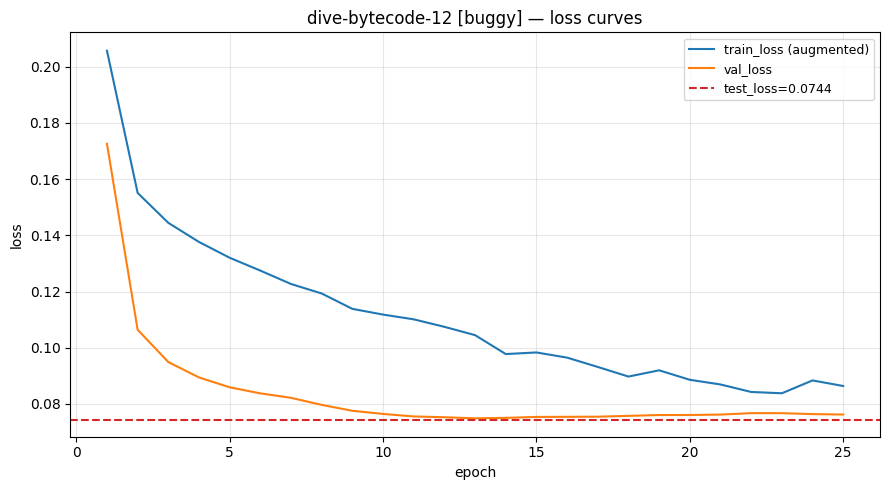

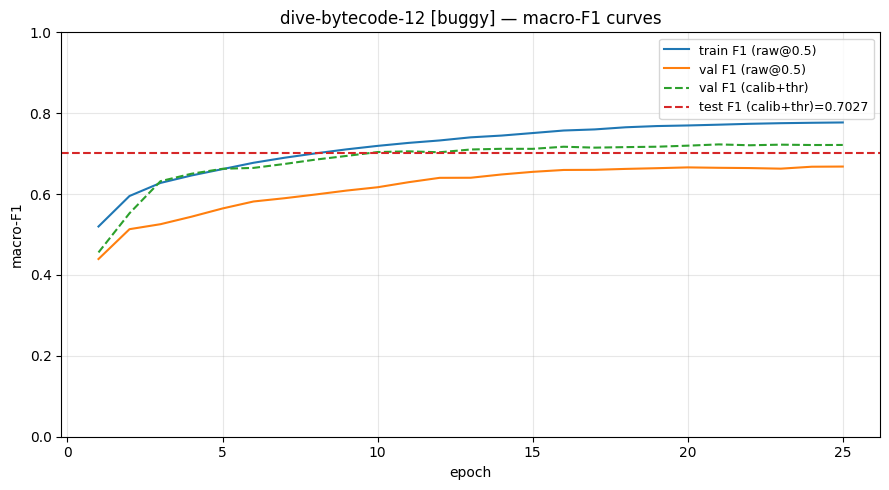

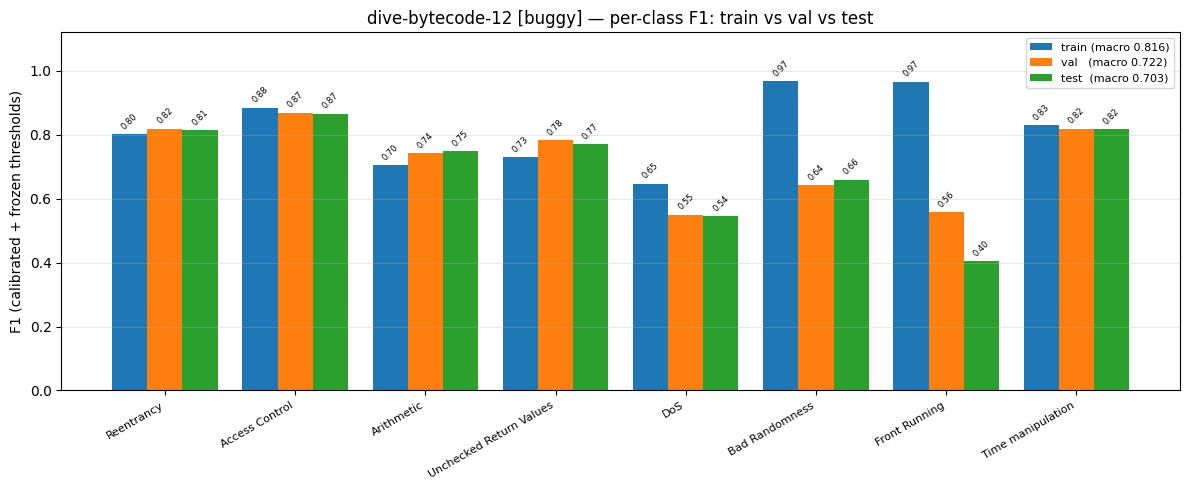

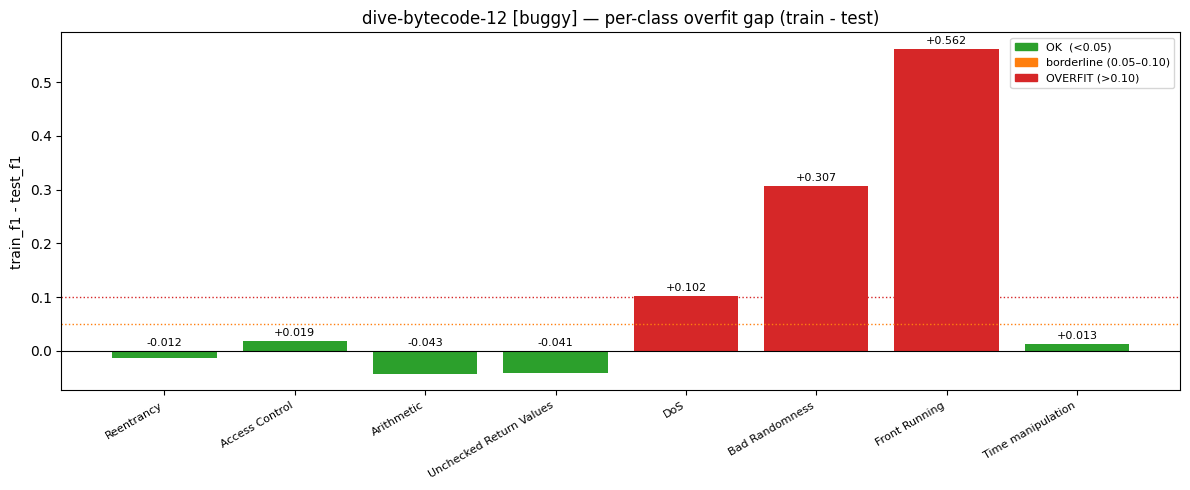

[02:37:12] Saved: loss_curves_buggy.png, f1_macro_curves_buggy.png, per_class_f1_train_val_test_buggy.png, per_class_overfit_gap_buggy.png
[02:37:12] macro-F1 (calib+thr)  train=0.8159  val=0.7221  test=0.7027  (train-test gap=+0.1132)
[02:37:12] === PER-CLASS OVERFIT GAP (train_f1 - test_f1, sorted descending) ===
[02:37:12]                Front Running  gap=+0.5621  [OVERFIT]
[02:37:12]               Bad Randomness  gap=+0.3068  [OVERFIT]
[02:37:12]                          DoS  gap=+0.1020  [OVERFIT]
[02:37:12]               Access Control  gap=+0.0186  [OK]
[02:37:12]            Time manipulation  gap=+0.0127  [OK]
[02:37:12]                   Reentrancy  gap=-0.0125  [OK]
[02:37:12]      Unchecked Return Values  gap=-0.0407  [OK]
[02:37:12]                   Arithmetic  gap=-0.0434  [OK]


In [20]:
try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    hist = pd.DataFrame(history)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(hist["epoch"], hist["train_loss"], color="tab:blue",   label="train_loss (augmented)")
    if "val_loss" in hist.columns:
        ax.plot(hist["epoch"], hist["val_loss"], color="tab:orange", label="val_loss")
    ax.axhline(test_loss, color="tab:red", linestyle="--", linewidth=1.5,
               label=f"test_loss={test_loss:.4f}")
    ax.set_xlabel("epoch"); ax.set_ylabel("loss")
    ax.set_title(f"dive-bytecode-12 [{AUG_SOURCE}] — loss curves")
    ax.legend(fontsize=9); ax.grid(alpha=0.3); fig.tight_layout()
    fig.savefig(OUT_DIR / f"loss_curves_{_ARM}.png", dpi=120); plt.show(); plt.close(fig)

    test_f1_macro = test_metrics_tuned["f1_macro"]
    fig, ax = plt.subplots(figsize=(9, 5))
    if "train_f1_macro_raw_05" in hist.columns:
        ax.plot(hist["epoch"], hist["train_f1_macro_raw_05"], color="tab:blue",
                label="train F1 (raw@0.5)")
    ax.plot(hist["epoch"], hist["val_f1_macro_raw_05"], color="tab:orange",
            label="val F1 (raw@0.5)")
    ax.plot(hist["epoch"], hist["f1_macro"], color="tab:green", linestyle="--",
            label="val F1 (calib+thr)")
    ax.axhline(test_f1_macro, color="tab:red", linestyle="--", linewidth=1.5,
               label=f"test F1 (calib+thr)={test_f1_macro:.4f}")
    ax.set_xlabel("epoch"); ax.set_ylabel("macro-F1"); ax.set_ylim(0, 1)
    ax.set_title(f"dive-bytecode-12 [{AUG_SOURCE}] — macro-F1 curves")
    ax.legend(fontsize=9); ax.grid(alpha=0.3); fig.tight_layout()
    fig.savefig(OUT_DIR / f"f1_macro_curves_{_ARM}.png", dpi=120); plt.show(); plt.close(fig)

    def _fold_f1(loader):
        lg, lb, _ = predict_with_loss(eval_model, loader)
        pr = apply_calibration(1 / (1 + np.exp(-lg)), frozen_calibrators)
        _, pc = multilabel_metrics(lb, pr, frozen_thresholds)
        return [pc[c]["f1"] for c in LABEL_COLS]

    f1_train = _fold_f1(train_eval_loader)
    f1_val   = _fold_f1(val_loader)
    f1_test  = [per_class_tuned[c]["f1"] for c in LABEL_COLS]

    x = np.arange(N_LABELS); bw = 0.27
    fig, ax = plt.subplots(figsize=(12, 5))
    bars_tr = ax.bar(x - bw, f1_train, bw, label=f"train (macro {np.mean(f1_train):.3f})")
    bars_v  = ax.bar(x,      f1_val,   bw, label=f"val   (macro {np.mean(f1_val):.3f})")
    bars_te = ax.bar(x + bw, f1_test,  bw, label=f"test  (macro {np.mean(f1_test):.3f})")
    for bars in (bars_tr, bars_v, bars_te):
        for bar in bars:
            h = bar.get_height()
            if h > 0.01:
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{h:.2f}",
                        ha="center", va="bottom", fontsize=6, rotation=45)
    ax.set_xticks(x); ax.set_xticklabels(LABEL_COLS, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("F1 (calibrated + frozen thresholds)"); ax.set_ylim(0, 1.12)
    ax.set_title(f"dive-bytecode-12 [{AUG_SOURCE}] — per-class F1: train vs val vs test")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3); fig.tight_layout()
    fig.savefig(OUT_DIR / f"per_class_f1_train_val_test_{_ARM}.png", dpi=120); plt.show(); plt.close(fig)

    gaps = [tr - te for tr, te in zip(f1_train, f1_test)]
    colors = ["tab:red" if g >= 0.10 else ("tab:orange" if g >= 0.05 else "tab:green") for g in gaps]
    fig, ax = plt.subplots(figsize=(12, 5))
    bars_gap = ax.bar(np.arange(N_LABELS), gaps, color=colors)
    for bar, g in zip(bars_gap, gaps):
        ax.text(bar.get_x() + bar.get_width() / 2, max(g, 0) + 0.005,
                f"{g:+.3f}", ha="center", va="bottom", fontsize=8)
    ax.axhline(0,    color="black",      linewidth=0.8)
    ax.axhline(0.05, color="tab:orange", linestyle=":", linewidth=1)
    ax.axhline(0.10, color="tab:red",    linestyle=":", linewidth=1)
    ax.set_xticks(np.arange(N_LABELS))
    ax.set_xticklabels(LABEL_COLS, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("train_f1 - test_f1")
    ax.set_title(f"dive-bytecode-12 [{AUG_SOURCE}] — per-class overfit gap (train - test)")
    ax.legend(handles=[
        mpatches.Patch(color="tab:green",  label="OK  (<0.05)"),
        mpatches.Patch(color="tab:orange", label="borderline (0.05–0.10)"),
        mpatches.Patch(color="tab:red",    label="OVERFIT (>0.10)"),
    ], fontsize=8); fig.tight_layout()
    fig.savefig(OUT_DIR / f"per_class_overfit_gap_{_ARM}.png", dpi=120); plt.show(); plt.close(fig)

    pd.DataFrame({"class": LABEL_COLS, "f1_train": f1_train, "f1_val": f1_val,
                  "f1_test": f1_test, "gap_train_test": gaps}).to_csv(
        OUT_DIR / f"f1_train_val_test_{_ARM}.csv", index=False)
    log(f"Saved: loss_curves_{_ARM}.png, f1_macro_curves_{_ARM}.png, "
        f"per_class_f1_train_val_test_{_ARM}.png, per_class_overfit_gap_{_ARM}.png")
    log(f"macro-F1 (calib+thr)  train={np.mean(f1_train):.4f}  val={np.mean(f1_val):.4f}  "
        f"test={np.mean(f1_test):.4f}  (train-test gap={np.mean(f1_train)-np.mean(f1_test):+.4f})")
    log("=== PER-CLASS OVERFIT GAP (train_f1 - test_f1, sorted descending) ===")
    for lab, g in sorted(zip(LABEL_COLS, gaps), key=lambda x: x[1], reverse=True):
        flag = "OVERFIT" if g >= 0.10 else ("borderline" if g >= 0.05 else "OK")
        log(f"  {lab:>26s}  gap={g:+.4f}  [{flag}]")
except Exception as e:
    log(f"Metrics plotting skipped: {e!r}")


## 21 — End-to-end inference check

Deployment path for a new bytecode hex string: strip CBOR → hex2bytes → disassemble (PUSH
operands stripped) → pad → model → calibrated probs → per-class thresholds → multi-label
prediction. The disassembly is the bulk of pre-model latency.


In [21]:
infer_model = eval_model.module if isinstance(eval_model, nn.DataParallel) else eval_model
infer_model.eval()


@torch.no_grad()
def infer_bytecode(bc_hex: str):
    toks = disassemble_strip_push(bc_hex, SEQ_LEN)
    X = torch.zeros(1, SEQ_LEN, dtype=torch.long, device=device)
    TM = torch.zeros(1, SEQ_LEN, dtype=torch.bool, device=device)
    L = min(len(toks), SEQ_LEN)
    X[0, :L]  = torch.tensor(toks[:L], dtype=torch.long, device=device)
    TM[0, :L] = True

    with autocast():
        main_logits, _ = infer_model(X, TM)
    raw = torch.sigmoid(main_logits).float().cpu().numpy()[0]
    cal = np.array([frozen_calibrators[i].transform([raw[i]])[0] for i in range(N_LABELS)])
    pred = (cal >= frozen_thresholds).astype(int)
    return cal, pred


rng = np.random.RandomState(0)
demo_rows = rng.choice(idx_te, size=8, replace=False)
log("=== INFERENCE DEMO (predicted vs true) ===")
for row in demo_rows:
    cid = df.iloc[row]["contractID"]
    cal, pred = infer_bytecode(bytecode_map[str(cid)])
    true = Y[row].astype(int)
    pl = [LABEL_COLS[i] for i in range(N_LABELS) if pred[i]]
    tl = [LABEL_COLS[i] for i in range(N_LABELS) if true[i]]
    tag = "OK  " if (pred == true).all() else "DIFF"
    log(f"  [{tag}] contract {cid}")
    log(f"        pred: {pl}")
    log(f"        true: {tl}")


BENCH_N = 256
bench_rows = rng.choice(idx_te, size=min(BENCH_N, len(idx_te)), replace=False)
bench_hex = [bytecode_map[str(df.iloc[r]["contractID"])] for r in bench_rows]

for h in bench_hex[:8]:        # warmup
    infer_bytecode(h)
if torch.cuda.is_available():
    torch.cuda.synchronize()

lat = []
for h in bench_hex:
    t0 = time.time()
    infer_bytecode(h)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    lat.append((time.time() - t0) * 1000.0)
lat = np.array(lat)

dev = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"
log("=== INFERENCE BENCHMARK (end-to-end: strip + disassemble + Transformer, batch=1) ===")
log(f"   device: {dev}")
log(f"   n_samples: {len(lat)}")
log(f"      p50_ms: {np.percentile(lat,50):.2f}")
log(f"      p90_ms: {np.percentile(lat,90):.2f}")
log(f"     mean_ms: {lat.mean():.2f}")
log(f"      max_ms: {lat.max():.2f}")

with open(OUT_DIR / f"inference_bench_{_ARM}.json", "w") as f:
    json.dump({"device": dev, "n_samples": int(len(lat)),
               "p50_ms": float(np.percentile(lat, 50)), "p90_ms": float(np.percentile(lat, 90)),
               "mean_ms": float(lat.mean()), "max_ms": float(lat.max())}, f, indent=2)
log(f"Wrote inference_bench_{_ARM}.json")


[02:37:12] === INFERENCE DEMO (predicted vs true) ===
[02:37:12]   [OK  ] contract 16795
[02:37:12]         pred: ['Reentrancy', 'Access Control', 'Arithmetic', 'Unchecked Return Values', 'DoS', 'Time manipulation']
[02:37:12]         true: ['Reentrancy', 'Access Control', 'Arithmetic', 'Unchecked Return Values', 'DoS', 'Time manipulation']
[02:37:12]   [DIFF] contract 12368
[02:37:12]         pred: ['Reentrancy', 'Access Control', 'Arithmetic', 'DoS', 'Time manipulation']
[02:37:12]         true: ['Reentrancy', 'Arithmetic', 'DoS', 'Time manipulation']
[02:37:12]   [DIFF] contract 6019
[02:37:12]         pred: ['Reentrancy', 'Access Control', 'DoS']
[02:37:12]         true: ['Reentrancy', 'Access Control', 'Arithmetic', 'DoS']
[02:37:12]   [OK  ] contract 7324
[02:37:12]         pred: ['Access Control']
[02:37:12]         true: ['Access Control']
[02:37:13]   [DIFF] contract 12014
[02:37:13]         pred: ['Reentrancy', 'Access Control', 'Arithmetic', 'DoS']
[02:37:13]         true: [

## 22 — Arm comparison table (aggregates every `metrics_arm_*.json`)

Reads all per-arm metric files written so far this session and tabulates macro-F1 +
per-class F1, **all on the same fixed real test set**. Run the notebook once per arm
( `AUG_SOURCE` in `"none"`, `"buggy"` ) in the same Kaggle session.


In [22]:
import json as _json

rows = []
for _f in sorted(OUT_DIR.glob("metrics_arm_*.json")):
    m = _json.load(open(_f))
    arm = m.get("aug_source", _f.stem.replace("metrics_arm_", ""))
    rec = {"arm": arm,
           "n_train": m.get("n_train"), "n_aug": m.get("n_train_aug"),
           "macro_f1": round(m["test_calibrated_tuned"]["f1_macro"], 4),
           "micro_f1": round(m["test_calibrated_tuned"]["f1_micro"], 4)}
    for c in LABEL_COLS:
        rec[c] = round(m["per_class"][c]["f1"], 4)
    rows.append(rec)

if rows:
    _order = {"none": 0, "buggy": 1}
    rows.sort(key=lambda r: _order.get(r["arm"], 9))
    cmp_df = pd.DataFrame(rows)
    cmp_df.to_csv(OUT_DIR / "comparison.csv", index=False)
    with open(OUT_DIR / "comparison.json", "w") as f:
        _json.dump(rows, f, indent=2)
    log("=== ARM COMPARISON (all arms on the SAME fixed real test set) ===")
    for line in cmp_df.to_string(index=False).splitlines():
        log("  " + line)
    if any(r["arm"] == "none" for r in rows):
        base = next(r for r in rows if r["arm"] == "none")["macro_f1"]
        for r in rows:
            if r["arm"] != "none":
                log(f"  delta macro-F1 ({r['arm']} - none) = {r['macro_f1'] - base:+.4f}")
    log("NOTE: dive-5 (0.747) and dive-11 (0.7634 buggy) were on different test sets / "
        "different modalities — references only, not apples-to-apples to this bytecode dive.")
else:
    log(f"Only the current arm ({AUG_SOURCE}) is present so far. Re-run with the other "
        f"AUG_SOURCE value in the same session to populate the comparison table.")


[02:37:21] === ARM COMPARISON (all arms on the SAME fixed real test set) ===
[02:37:21]     arm  n_train  n_aug  macro_f1  micro_f1  Reentrancy  Access Control  Arithmetic  Unchecked Return Values    DoS  Bad Randomness  Front Running  Time manipulation
[02:37:21]   buggy    15286   4101    0.7027    0.7845      0.8141           0.865       0.748                   0.7695 0.5448          0.6598         0.4041             0.8164
[02:37:21] NOTE: dive-5 (0.747) and dive-11 (0.7634 buggy) were on different test sets / different modalities — references only, not apples-to-apples to this bytecode dive.


## Summary

**dive-bytecode-12 = modality revival + diversified synthetic + tighter preprocessing.**

**Pipeline.**
1. Resolve each contract's hex bytecode (real → `Bytecode_filled.csv`; synthetic → `final/Synthetic_Bytecode.csv`).
2. Strip CBOR/SWARM metadata trailer (dive-5).
3. Hex → bytes; disassemble each byte to one opcode-mnemonic token.
4. **Strip PUSH operands entirely** — vocab = 260 (specials + 256 opcode slots).
5. **Deduplicate the train fold** by post-strip opcode-token-sequence hash; val/test untouched.
6. Pad/truncate to `SEQ_LEN=4096`; train the dive-5 single-pass Transformer.

**Outputs (`/kaggle/working/`, suffixed by arm).**
- `best_model_<arm>.pt` — EMA weights + calibrators + frozen thresholds.
- `last_state_<arm>.pt` — full resumable state.
- `metrics_arm_<arm>.json` — the per-arm summary used by cell 22's comparison table.
- `loss_curves_<arm>.png`, `f1_macro_curves_<arm>.png`,
  `per_class_f1_train_val_test_<arm>.png`, `per_class_overfit_gap_<arm>.png`.

**What to read first.**
1. Gates (cell 5): leakage, identical-test (4,466 rows).
2. Cell 7 dedup report — `duplicates_within_train` and the cross-fold opcode-sequence
   counts. Large cross-fold counts flag modality-level near-duplication that contractID
   gates miss.
3. **Cell 22's arm comparison** — `delta macro-F1 (buggy − none)` is the headline:
   does the new diverse synthetic lift the honest bytecode-modality test F1?
4. Per-class overfit gap on Bad Randomness / Front Running — should shrink vs. the old
   templated bytecode synthetic if memorisation has been broken.
